## Importing Requird Packages


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import openpyxl 

## 1. COMBINING DATA


In [3]:

all_dfs_1=[]
all_dfs_2=[]
folder_path_1=Path(r"C:\Users\thatt\OneDrive\Desktop\EV_DATA_ANALYSIS\TGNPDCL")
folder_path_2=Path(r"C:\Users\thatt\OneDrive\Desktop\EV_DATA_ANALYSIS\TGSPDCL")

for sub in folder_path_1.iterdir():
    if sub.is_dir():
        for file in sub.glob("*.csv"):
            
            temp_df=pd.read_csv(file)
            temp_df['Year']=sub.name
            temp_df['Source_File']=file.name
            all_dfs_1.append(temp_df)
df1=pd.concat(all_dfs_1,ignore_index=True)
    
for sub in folder_path_2.iterdir():
    if sub.is_dir():
        for file in sub.glob("*.csv"):
            temp_df=pd.read_csv(file)
            temp_df['Year']=sub.name
            temp_df['Source_File']=file.name
            all_dfs_2.append(temp_df)
df2=pd.concat(all_dfs_2,ignore_index=True)



In [4]:
print("North Side Data:",df1.info())


print("South Side Data:",df2.info())

<class 'pandas.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          3400 non-null   str    
 1   Division        3400 non-null   str    
 2   SubDivision     3400 non-null   str    
 3   Section         3400 non-null   str    
 4   Area            3400 non-null   str    
 5   CatCode         3400 non-null   int64  
 6   CatDesc         3400 non-null   str    
 7   TotServices     3400 non-null   int64  
 8   BilledServices  3400 non-null   int64  
 9   Units           3400 non-null   float64
 10  Load            3400 non-null   float64
 11  Year            3400 non-null   str    
 12  Source_File     3400 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 345.4 KB
North Side Data: None
<class 'pandas.DataFrame'>
RangeIndex: 12898 entries, 0 to 12897
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  

In [5]:
df1.columns

Index(['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'CatCode',
       'CatDesc', 'TotServices', 'BilledServices', 'Units', 'Load', 'Year',
       'Source_File'],
      dtype='str')

##### Fixing the column missmatch

In [6]:
df2.rename(columns={"billdservices":"billedservices"})

df1.columns=df1.columns.str.lower()

##### Handling the missing values in billedservices - (south data set)

In [7]:
df2[df2['billdservices'].isna()].shape
# there are 554 missing columns found 

(554, 13)

In [8]:
df2.columns

Index(['circle', 'division', 'subdivision', 'section', 'area', 'catdesc',
       'catcode', 'totservices', 'billdservices', 'units', 'load', 'Year',
       'Source_File'],
      dtype='str')

In [9]:
df2.rename(columns={'Source_File':'source_file'},inplace=True)
df2.rename(columns={'Year':'year'},inplace=True)

In [10]:
#  Checking Weather the missing values are concentrated in any particular month 

# month wise across all years
print(df2[df2['billdservices'].isna()]['source_file'].value_counts())

# missing summary 

missing_summary=df2.groupby('year')['billdservices'].agg(total_rows="size",non_missing="count")

missing_summary['missing']=(missing_summary['total_rows']-missing_summary['non_missing'])

missing_summary['percentage']=(missing_summary['missing'] / missing_summary['total_rows'])*100

print(missing_summary)


source_file
January.csv      61
April.csv        58
June.csv         56
March.csv        55
February.csv     54
May.csv          53
July.csv         49
August.csv       47
December.csv     33
October.csv      30
September.csv    30
November.csv     28
Name: count, dtype: int64
      total_rows  non_missing  missing  percentage
year                                              
2023        1609         1509      100     6.21504
2024        2654         2566       88     3.31575
2025        4755         4533      222     4.66877
2026        3880         3736      144     3.71134


In [11]:
df2[df2['billdservices'].isna()][[ "circle","division","subdivision","section","area","totservices","billdservices","units","load","year", "source_file"]].head(25)


,circle,division,subdivision,section,area,totservices,billdservices,units,load,year,source_file
15,CYBERCITY,KONDAPUR,KPHB,BALAJI NAGAR,MOOSAPET,1,NaN,0.0,5.0,2023,April.csv
17,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,1,NaN,0.0,5.0,2023,April.csv
36,MAHABOOBNAGAR,JADCHERLA,RAJAPUR,RAJAPUR,RANGAREDDYGUDA,1,NaN,0.0,30.0,2023,April.csv
45,MEDCHAL,MEDCHAL,QUTBULLAPUR,KOMPALLY,KOMPALLY,1,NaN,0.0,30.0,2023,April.csv
56,NALGONDA,NALGONDA,NALGONDA RURAL,CHITYAL,GUNDRAMPALLY,2,NaN,0.0,50.0,2023,April.csv
66,SANGAREDDY,SANGAREDDY,SADASIVPET,KONDAPUR,KDPR HV 3,2,NaN,0.0,60.0,2023,April.csv
75,SAROORNAGAR,CHAMPAPET,VANASTHALIPURAM,BN REDDY NAGAR,HASTINAPURAM CENTR,1,NaN,0.0,22.0,2023,April.csv
87,SECUNDERABAD,PARADISE,JAMES STREET,CLOCK TOWER,ONLY CT METERS,1,NaN,0.0,54.0,2023,April.csv
90,SECUNDERABAD,BOWENPALLY,BOWENPALLY,NEW BOWENPALLY,DHANA LAXMI COLONY (GRP-B),1,NaN,0.0,10.0,2023,April.csv
120,CYBERCITY,GACHIBOWLI,GACHIBOWLI,TARANAGAR,CHANDA NAGAR HV,1,NaN,0.0,54.0,2023,August.csv


In [12]:

missing = df2[df2["billdservices"].isna()]

print("Total missing:", len(missing))

print("Units = 0:",
(missing["units"] == 0).sum())

print("Units > 0:",
(missing["units"] > 0).sum())

print("Load = 0:",
(missing["load"] == 0).sum())

print("Load > 0:",
(missing["load"] > 0).sum())

print("Totservices = 0:",
(missing["totservices"] == 0).sum())

print("Totservices > 0:",
(missing["totservices"] > 0).sum())

print(missing['totservices'].value_counts().sort_index())

Total missing: 554
Units = 0: 554
Units > 0: 0
Load = 0: 0
Load > 0: 554
Totservices = 0: 0
Totservices > 0: 554
totservices
1    519
2     32
3      3
Name: count, dtype: int64


##### Finding-1: "554 South-side records have missing billing-service values, and all 554 have zero units, positive load, and 1–3 total services".

##### Handling the duplicates 



In [13]:

key_cols = [
    "circle","division","subdivision","section","area","catcode","year","source_file"
]
print("Norht Side:",df1.duplicated(subset=key_cols,keep=False).sum())
print("South Side:",df2.duplicated(subset=key_cols,keep=False).sum())
# keep='first'
print(df1.duplicated().sum())
print(df2.duplicated().sum())

Norht Side: 0
South Side: 128
0
64


In [14]:
south_duplicates=df2[df2.duplicated(keep=False)]

print(south_duplicates.head(30).to_string(index=False))

       circle      division   subdivision             section                           area              catdesc  catcode  totservices  billdservices   units  load year source_file
BANJARA HILLS   GREEN LANDS  SANATH NAGAR           BORABANDA               GRC HV BORABANDA EV CHARGING STATIONS        9            1            1.0  1830.0  53.0 2025  August.csv
BANJARA HILLS   GREEN LANDS    GREENLANDS            BEGUMPET         GRC - P.GADDA, P.NAGAR EV CHARGING STATIONS        9            1            1.0   727.0  10.0 2025  August.csv
BANJARA HILLS   GREEN LANDS    GREENLANDS            BEGUMPET                  GRC. SHYAMLAL EV CHARGING STATIONS        9            1            1.0   217.0  22.0 2025  August.csv
BANJARA HILLS   GREEN LANDS    GREENLANDS          GREENLANDS              GRC HV GREENLANDS EV CHARGING STATIONS        9            1            1.0   168.0  10.0 2025  August.csv
BANJARA HILLS   GREEN LANDS  SANATH NAGAR           ERRAGADDA    NEW ERRAGADDA-BANJARA NAG

In [15]:
print(
    south_duplicates
    .groupby(key_cols, dropna=False)
    .size()
    .value_counts()
)



duplicated_groups=(
    south_duplicates.groupby(key_cols,dropna=False).agg(
        row=('units','size'),
        unique_units=("units", "nunique"),
        unique_load=("load", "nunique"),
        unique_totservices=("totservices", "nunique"),
        unique_billdservices=("billdservices", "nunique")
    )
)

2    64
Name: count, dtype: int64


##### Finding-2: " There are 64 duplicates records with same values we are removing them ".


In [16]:
df2_clean=df2.drop_duplicates().copy()


print("Befor Cleaning :", df2.shape)
print("After Cleaning :", df2_clean.shape)



Befor Cleaning : (12898, 13)
After Cleaning : (12834, 13)


##### Numerical validation

In [17]:
#  Checking the negative values 
numarical_columns=["totservices","billdservices","units", "load"]

for col in numarical_columns:
    print(f"{col}-- {(df2_clean[col]<0).sum()} negative valuess")

totservices-- 0 negative valuess
billdservices-- 0 negative valuess
units-- 13 negative valuess
load-- 0 negative valuess


In [18]:
neg_units=df2_clean[df2_clean['units']<0]
neg_locations=neg_units[["circle", "division", "subdivision", "section", "area"]].drop_duplicates()

location_history=df2_clean.merge(neg_locations,on=["circle", "division", "subdivision", "section", "area"],how="inner")

location_history = location_history[["circle","division","subdivision","section","area","year","source_file","totservices","billdservices","units","load"]].sort_values(["circle", "division", "subdivision", "section", "area", "year", "source_file"])

location_history


,circle,division,subdivision,section,area,year,source_file,totservices,billdservices,units,load
1,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023,April.csv,1,NaN,0.0,5.0
9,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023,August.csv,1,1.0,511.0,5.0
16,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023,December.csv,1,1.0,5099.0,5.0
36,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023,July.csv,1,1.0,-323.0,5.0
44,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023,June.csv,1,1.0,375.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
316,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GOKUL NAGAR,2026,January.csv,1,1.0,242.0,5.0
321,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GOKUL NAGAR,2026,July.csv,1,1.0,249.0,5.0
330,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GOKUL NAGAR,2026,June.csv,1,1.0,349.0,5.0
335,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GOKUL NAGAR,2026,March.csv,1,1.0,279.0,5.0


In [19]:
month_map={"January.csv": 1,"February.csv": 2,"March.csv": 3,"April.csv": 4,"May.csv": 5,"June.csv": 6,"July.csv": 7,"August.csv": 8,"September.csv": 9,"October.csv": 10,"November.csv": 11,"December.csv": 12}
df2_clean['month']=df2_clean['source_file'].map(month_map)


df2_clean['date']=pd.to_datetime(df2_clean['year'].astype(str)+"-"+df2_clean['month'].astype(str)+"-01")

In [20]:
df2_clean[df2_clean['units']<0][[
        "circle","division","subdivision","section","area","date","totservices","billdservices","units","load"]].sort_values('date')

,circle,division,subdivision,section,area,date,totservices,billdservices,units,load
911,HYDERABAD CENTRAL,AZAMABAD,AMBERPET,GOLNAKA,MARUTHI NAGAR,2023-03-01,1,1.0,-867.0,17.0
941,RAJENDRA NAGAR,RAJENDRA NAGAR,GAGANPAHAD,MD PALLY,VINAYAK NAGAR,2023-03-01,1,1.0,-462.0,5.0
1020,HYDERABAD CENTRAL,AZAMABAD,AMBERPET,GOLNAKA,MARUTHI NAGAR,2023-05-01,1,1.0,-851.0,17.0
1086,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GOKUL NAGAR,2023-05-01,1,1.0,-102.0,5.0
866,SECUNDERABAD,BOWENPALLY,RR NAGAR,I.D.P.L.,PRASHANTH NAGAR CLY (GRP-B),2023-06-01,2,2.0,-150.0,4.0
634,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,POKALWADA,2023-07-01,1,1.0,-323.0,5.0
3191,HYDERABAD CENTRAL,AZAMABAD,AMBERPET,GOLNAKA,MARUTHI NAGAR,2024-03-01,1,1.0,-1740.0,17.0
3465,RAJENDRA NAGAR,RAJENDRA NAGAR,SHAMSHABAD,SHAMSHABAD,NEW SHAMSHABAD,2024-05-01,1,1.0,-600.0,49.0
3636,HYDERABAD SOUTH,CHARMINAR,MIR ALAM,KISHANBAGH,BHARATH NAGAR,2024-11-01,1,1.0,-107.0,5.0
3758,SECUNDERABAD,BOWENPALLY,RR NAGAR,RANGA REDDY NAGAR,ASBESTOS CLY-II 415-812(GRP-B),2024-11-01,1,1.0,-38.0,2.0


In [21]:
# flagging the 13 negative unit values as anomaly

df2_clean["units_anomaly"]=df2_clean['units']<0

##### Finding-3 : "13 records contained negative values in the units field and were flagged as data-quality anomalies. The original values were retained rather than imputed or deleted".

In [22]:
# Checking is any zero valus exists in an numarical columns 

for col in numarical_columns:
    print(f"{col}: {(df2_clean[col] == 0).sum()} zero values")

totservices: 0 zero values
billdservices: 0 zero values
units: 3033 zero values
load: 0 zero values


In [23]:
# Checking the 3033 zeros in  units column 

zero_units = df2_clean[df2_clean["units"] == 0]
print("Total zero-unit records:", len(zero_units))
print("\nBilldservices status:")
print(zero_units["billdservices"].isna().value_counts())
print("\nTotservices:")
print(zero_units["totservices"].value_counts())
print("\nLoad summary:")
print(zero_units["load"].describe())


Total zero-unit records: 3033

Billdservices status:
billdservices
False    2481
True      552
Name: count, dtype: int64

Totservices:
totservices
1    2714
2     293
3      24
4       2
Name: count, dtype: int64

Load summary:
count    3033.000000
mean       43.693373
std        28.046388
min         2.000000
25%        20.000000
50%        54.000000
75%        54.000000
max       216.000000
Name: load, dtype: float64


##### Checking extreme values (outliers)

In [24]:
# Chcking the distrubution of units
print(df2_clean.describe())

print(df2_clean["units"].quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

       catcode   totservices  billdservices         units          load  \
count  12834.0  12834.000000   12282.000000  12834.000000  12834.000000   
mean       9.0      1.282297       1.273490   2633.399953     51.093053   
min        9.0      1.000000       1.000000  -1740.000000      2.000000   
25%        9.0      1.000000       1.000000      2.000000     22.000000   
50%        9.0      1.000000       1.000000    569.500000     54.000000   
75%        9.0      1.000000       1.000000   2897.750000     54.000000   
max        9.0      7.000000       7.000000  88565.000000    469.000000   
std        0.0      0.663308       0.643935   5488.214050     42.610748   

              month                        date  
count  12834.000000                       12834  
mean       6.250273  2025-04-13 00:49:42.328190  
min        1.000000         2023-01-01 00:00:00  
25%        4.000000         2024-08-01 00:00:00  
50%        6.000000         2025-07-01 00:00:00  
75%        9.000000     

In [25]:
# Chcking the distrubution of load

print(df2_clean["load"].quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

0.01      2.0
0.25     22.0
0.50     54.0
0.75     54.0
0.90    108.0
0.95    130.0
0.99    220.0
Name: load, dtype: float64


In [26]:
# Top 20 largest values of load and units 

df2_clean.nlargest(20,'units')[["circle", "area", "totservices", "billdservices", "units", "load", "year", "source_file"]]


,circle,area,totservices,billdservices,units,load,year,source_file
11504,CYBERCITY,NALLAGADLA HV,7,6.0,88565.0,469.0,2026,June.csv
11007,CYBERCITY,NALLAGADLA HV,7,7.0,85199.0,469.0,2026,July.csv
12473,CYBERCITY,NALLAGADLA HV,6,6.0,74780.0,415.0,2026,May.csv
9543,CYBERCITY,NALLAGADLA HV,6,6.0,72553.0,415.0,2026,August.csv
9557,CYBERCITY,HV GOWLI DODDI,3,3.0,63904.0,162.0,2026,August.csv
11491,CYBERCITY,HV GOWLI DODDI,3,2.0,58841.0,162.0,2026,June.csv
11858,SECUNDERABAD,C T METERS,4,4.0,58631.0,298.0,2026,June.csv
10996,CYBERCITY,HV GOWLI DODDI,3,3.0,56573.0,162.0,2026,July.csv
10052,CYBERCITY,NALLAGADLA HV,4,4.0,55233.0,241.0,2026,February.csv
11361,SECUNDERABAD,C.T.METER GRC (GRP-M),3,3.0,54429.0,229.0,2026,July.csv


In [27]:
df2_clean.nlargest(20,'load')[["circle", "area", "totservices", "billdservices", "units", "load", "year", "source_file"]]

,circle,area,totservices,billdservices,units,load,year,source_file
11007,CYBERCITY,NALLAGADLA HV,7,7.0,85199.0,469.00,2026,July.csv
11504,CYBERCITY,NALLAGADLA HV,7,6.0,88565.0,469.00,2026,June.csv
9543,CYBERCITY,NALLAGADLA HV,6,6.0,72553.0,415.00,2026,August.csv
12473,CYBERCITY,NALLAGADLA HV,6,6.0,74780.0,415.00,2026,May.csv
8195,CYBERCITY,CT-APHB COLONY,6,6.0,33706.0,336.00,2025,October.csv
9869,SAROORNAGAR,CT METERS,6,6.0,11909.0,324.00,2026,August.csv
11295,SAROORNAGAR,CT METERS,6,6.0,14647.0,324.00,2026,July.csv
11841,SAROORNAGAR,CT METERS,6,5.0,14980.0,324.00,2026,June.csv
9836,SANGAREDDY,ISNP HV-2,7,5.0,8598.0,323.00,2026,August.csv
9551,CYBERCITY,CT GOVT,5,5.0,18312.0,316.16,2026,August.csv


In [28]:
df2_clean[df2_clean['units_anomaly']][["circle", "area", "totservices", "billdservices",
     "units", "load", "year", "source_file"]].sort_values(["year", "source_file"]
                                                          )

,circle,area,totservices,billdservices,units,load,year,source_file
634,CYBERCITY,POKALWADA,1,1.0,-323.0,5.0,2023,July.csv
866,SECUNDERABAD,PRASHANTH NAGAR CLY (GRP-B),2,2.0,-150.0,4.0,2023,June.csv
911,HYDERABAD CENTRAL,MARUTHI NAGAR,1,1.0,-867.0,17.0,2023,March.csv
941,RAJENDRA NAGAR,VINAYAK NAGAR,1,1.0,-462.0,5.0,2023,March.csv
1020,HYDERABAD CENTRAL,MARUTHI NAGAR,1,1.0,-851.0,17.0,2023,May.csv
1086,SECUNDERABAD,GOKUL NAGAR,1,1.0,-102.0,5.0,2023,May.csv
3191,HYDERABAD CENTRAL,MARUTHI NAGAR,1,1.0,-1740.0,17.0,2024,March.csv
3465,RAJENDRA NAGAR,NEW SHAMSHABAD,1,1.0,-600.0,49.0,2024,May.csv
3636,HYDERABAD SOUTH,BHARATH NAGAR,1,1.0,-107.0,5.0,2024,November.csv
3758,SECUNDERABAD,ASBESTOS CLY-II 415-812(GRP-B),1,1.0,-38.0,2.0,2024,November.csv


In [29]:
df1['month']=df1['source_file'].map(month_map)

df1['date']=pd.to_datetime(df1['year'].astype(str)+"-"+df1['month'].astype(str)+"-01")

df1['units_anomaly']=df1['units']<0

df2_clean['discom']='TGSPDCL'
df1['discom']='TGNPDCL'

df1['catdesc']='EV CHARGING STATIONS'
df2_clean['catdesc']='EV CHARGING STATIONS'
df2_clean.rename(columns={'billdservices':'billedservices'},inplace=True)

df2_clean = df2_clean.rename(
    columns={"units_anomaly": "units_negative_flag"}
)

df1 = df1.rename(
    columns={"units_anomaly": "units_negative_flag"}
)

In [30]:
final_columns = [
    "discom","year","month","date","circle","division","subdivision","section","area","catcode","catdesc","totservices","billedservices","units","load",
"source_file","units_negative_flag"
]

df_final_combined=pd.concat([df1[final_columns],df2_clean[final_columns]],ignore_index=True)

In [31]:
df_final_combined

,discom,year,month,date,circle,division,subdivision,section,area,catcode,catdesc,totservices,billedservices,units,load,source_file,units_negative_flag
0,TGNPDCL,2023,4,2023-04-01,HANUMAKONDA,HANAMKONDA/RURAL,PARKAL,DAMERA,MUSTYALAPALLY,9,EV CHARGING STATIONS,1,1.0,1.0,30.0,April.csv,False
1,TGNPDCL,2023,4,2023-04-01,HANUMAKONDA,HANAMKONDA/RURAL,PARKAL,PARKAL-TOWN,PARKAL,9,EV CHARGING STATIONS,1,1.0,147.0,30.0,April.csv,False
2,TGNPDCL,2023,4,2023-04-01,HANUMAKONDA,HANAMKONDA/TOWN,HANAMKONDA(T),NAKKALAGUTTA,BALASAMUDRAM,9,EV CHARGING STATIONS,1,1.0,594.0,60.0,April.csv,False
3,TGNPDCL,2023,4,2023-04-01,HANUMAKONDA,HANAMKONDA/TOWN,HANAMKONDA(T),SUBEDARI,BONDIVAGU,9,EV CHARGING STATIONS,1,1.0,6.0,30.0,April.csv,False
4,TGNPDCL,2023,4,2023-04-01,HANUMAKONDA,HANAMKONDA/TOWN,HANAMKONDA(T),SUBEDARI,HUNTER ROAD,9,EV CHARGING STATIONS,1,1.0,28.0,30.0,April.csv,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16229,TGSPDCL,2026,5,2026-05-01,YADADRI,BHONGIR,BIBINAGAR,BIBINAGAR,KONDAMADUGU,9,EV CHARGING STATIONS,1,1.0,0.0,60.0,May.csv,False
16230,TGSPDCL,2026,5,2026-05-01,YADADRI,CHOUTUPPAL,CHOUTUPPAL,CHOUTUPPAL,LAKKARAM,9,EV CHARGING STATIONS,1,1.0,40.0,54.0,May.csv,False
16231,TGSPDCL,2026,5,2026-05-01,YADADRI,BHONGIR,BHONGIR,BHONGIR - TOWN,PAGIDIPALLY,9,EV CHARGING STATIONS,2,2.0,1158.0,108.0,May.csv,False
16232,TGSPDCL,2026,5,2026-05-01,YADADRI,CHOUTUPPAL,CHOUTUPPAL,CHOUTUPPAL,LINGOJI GUDEM,9,EV CHARGING STATIONS,2,2.0,3761.0,94.0,May.csv,False


In [32]:
df_final_combined.shape

(16234, 17)

In [33]:
# Data Checking after combining
print(df_final_combined['discom'].value_counts())

print(df_final_combined['date'].min())
print(df_final_combined['date'].max())

print(df_final_combined.info())

print(df_final_combined.shape)

print(df_final_combined["discom"].value_counts())

print(df_final_combined["year"].value_counts().sort_index())


print(df_final_combined["units_negative_flag"].value_counts())
print(df_final_combined["billedservices"].isna().sum())


discom
TGSPDCL    12834
TGNPDCL     3400
Name: count, dtype: int64
2023-01-01 00:00:00
2026-08-01 00:00:00


<class 'pandas.DataFrame'>
RangeIndex: 16234 entries, 0 to 16233
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   discom               16234 non-null  str           
 1   year                 16234 non-null  str           
 2   month                16234 non-null  int64         
 3   date                 16234 non-null  datetime64[us]
 4   circle               16234 non-null  str           
 5   division             16234 non-null  str           
 6   subdivision          16234 non-null  str           
 7   section              16234 non-null  str           
 8   area                 16234 non-null  str           
 9   catcode              16234 non-null  int64         
 10  catdesc              16234 non-null  str           
 11  totservices          16234 non-null  int64         
 12  billedservices       15682 non-null  float64       
 13  units                16234 non-null  float

In [34]:
# saving it to an excel 

df_final_combined.to_excel("telangana_ev_consumption_master_2023_2026.xlsx",index=False)

## 2. Exploratory Data Analysis (EDA)

In [35]:
df_final_combined[["totservices", "billedservices", "units", "load"]].describe()

,totservices,billedservices,units,load
count,16234.000000,15682.000000,16234.000000,16234.000000
mean,1.250277,1.233134,2241.466860,52.975923
std,0.620604,0.610876,5007.521329,238.812079
min,1.000000,0.000000,-1740.000000,0.030000
25%,1.000000,1.000000,1.000000,25.000000
50%,1.000000,1.000000,391.000000,53.000000
75%,1.000000,1.000000,2334.000000,54.000000
max,7.000000,7.000000,88565.000000,30030.000000


##### max load is 30030 which look doubtfull ... 


In [36]:
df_final_combined[["totservices", "billedservices", "units", "load"]].sum()



df_final_combined.groupby("discom")[["totservices", "billedservices", "units", "load"]].sum()

,totservices,billedservices,units,load
discom,,,,
TGNPDCL,3840,3697.0,2590918.0,204282.89
TGSPDCL,16457,15641.0,33797055.0,655728.24


In [37]:
df_final_combined.nlargest(20, "load")[
    [
        "discom",
        "circle",
        "area",
        "totservices",
        "billedservices",
        "units",
        "load",
        "year",
        "source_file"
    ]
]

,discom,circle,area,totservices,billedservices,units,load,year,source_file
131,TGNPDCL,NIZAMABAD,SN PURAM,2,1.0,25.0,30030.00,2023,January.csv
14343,TGSPDCL,CYBERCITY,NALLAGADLA HV,7,7.0,85199.0,469.00,2026,July.csv
14840,TGSPDCL,CYBERCITY,NALLAGADLA HV,7,6.0,88565.0,469.00,2026,June.csv
12879,TGSPDCL,CYBERCITY,NALLAGADLA HV,6,6.0,72553.0,415.00,2026,August.csv
15809,TGSPDCL,CYBERCITY,NALLAGADLA HV,6,6.0,74780.0,415.00,2026,May.csv
11531,TGSPDCL,CYBERCITY,CT-APHB COLONY,6,6.0,33706.0,336.00,2025,October.csv
13205,TGSPDCL,SAROORNAGAR,CT METERS,6,6.0,11909.0,324.00,2026,August.csv
14631,TGSPDCL,SAROORNAGAR,CT METERS,6,6.0,14647.0,324.00,2026,July.csv
15177,TGSPDCL,SAROORNAGAR,CT METERS,6,5.0,14980.0,324.00,2026,June.csv
13172,TGSPDCL,SANGAREDDY,ISNP HV-2,7,5.0,8598.0,323.00,2026,August.csv


In [38]:
sn_puram_history = df_final_combined[
    (df_final_combined["discom"] == "TGNPDCL") &
    (df_final_combined["circle"] == "NIZAMABAD") &
    (df_final_combined["area"] == "SN PURAM")
][
    [
        "date",
        "totservices",
        "billedservices",
        "units",
        "load"
    ]
].sort_values("date")

sn_puram_history

,date,totservices,billedservices,units,load
131,2023-01-01,2,1.0,25.0,30030.0
106,2023-02-01,1,1.0,1.0,30.0
236,2023-03-01,1,1.0,141.0,30.0
26,2023-04-01,1,1.0,63.0,30.0
242,2023-05-01,1,1.0,279.0,30.0
195,2023-06-01,1,1.0,235.0,30.0
167,2023-07-01,1,1.0,86.0,30.0
62,2023-08-01,1,1.0,106.0,30.0
348,2023-09-01,1,1.0,49.0,30.0
327,2023-10-01,1,1.0,68.0,30.0


##### Data correction: TGNPDCL NIZAMABAD – SN PURAM had a load value of 30,030 in January 2023. Based on the same location's consistent load of 30 across subsequent months, the value was corrected to 30.


In [39]:
df_final_combined.loc[
    (df_final_combined["discom"] == "TGNPDCL") &
    (df_final_combined["circle"] == "NIZAMABAD") &
    (df_final_combined["area"] == "SN PURAM") &
    (df_final_combined["year"] == '2023') &
    (df_final_combined["month"] == 1) &
    (df_final_combined["load"] == 30030),
    "load"
]=30

***
##### Monthly consumption
***

In [40]:
# monthly consumption table.....................................................................................................................
monthly_units=df_final_combined.groupby('date',as_index=False)['units'].sum().sort_values('date')
monthly_units

,date,units
0,2023-01-01,61844.0
1,2023-02-01,66862.0
2,2023-03-01,66509.0
3,2023-04-01,77571.0
4,2023-05-01,90941.0
5,2023-06-01,104138.0
6,2023-07-01,106162.0
7,2023-08-01,137007.0
8,2023-09-01,165945.0
9,2023-10-01,160789.0


In [41]:
yearly_unit=df_final_combined.groupby('year',as_index=False)['units'].sum().sort_values('year')
yearly_unit

,year,units
0,2023,1511116.0
1,2024,4875533.0
2,2025,11115134.0
3,2026,18886190.0


In [42]:
print('Number of Months:',monthly_units.shape[0])
print(monthly_units.loc[monthly_units['units'].idxmax()])
print(monthly_units.loc[monthly_units['units'].idxmin()])

Number of Months: 44
date     2026-08-01 00:00:00
units              2999258.0
Name: 43, dtype: object
date     2023-01-01 00:00:00
units                61844.0
Name: 0, dtype: object


##### Finding - EV charging electricity consumption shows a strong overall upward trend, despite month-to-month fluctuations.

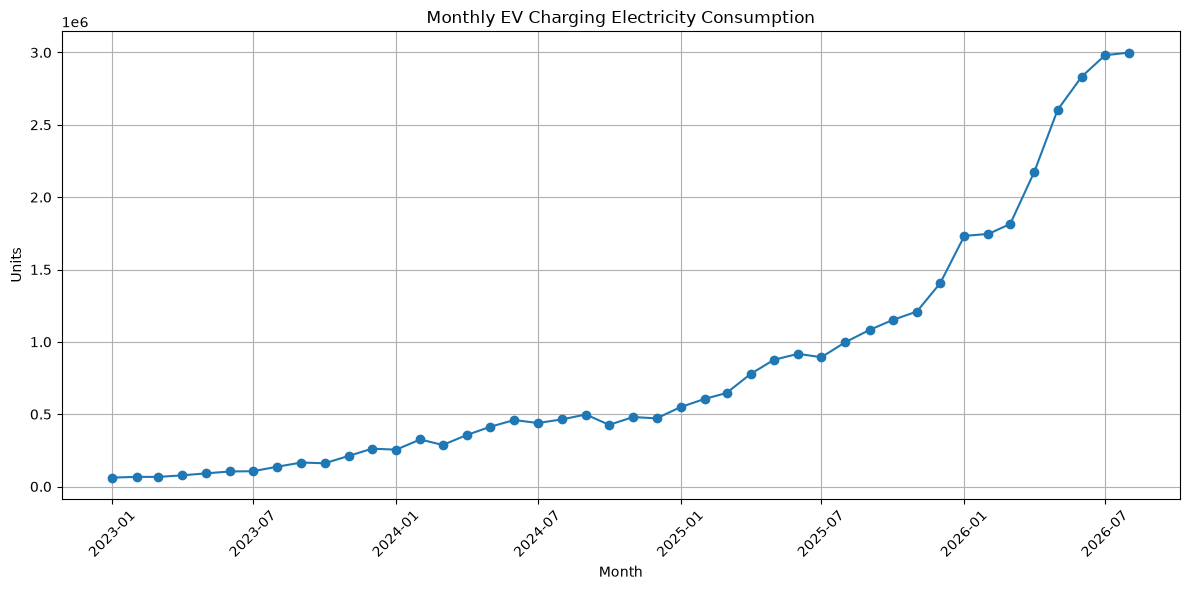

In [43]:
# Viz --1 

plt.figure(figsize=(12,6))

plt.plot(
    monthly_units['date'],monthly_units['units'],marker="o"
)
plt.title("Monthly EV Charging Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
# checking the sales trend in TGNPDCL and TGSPDCL......................................................................................
monthly_discom=df_final_combined.groupby(['date','discom'],as_index=False)['units'].sum().sort_values('date') 

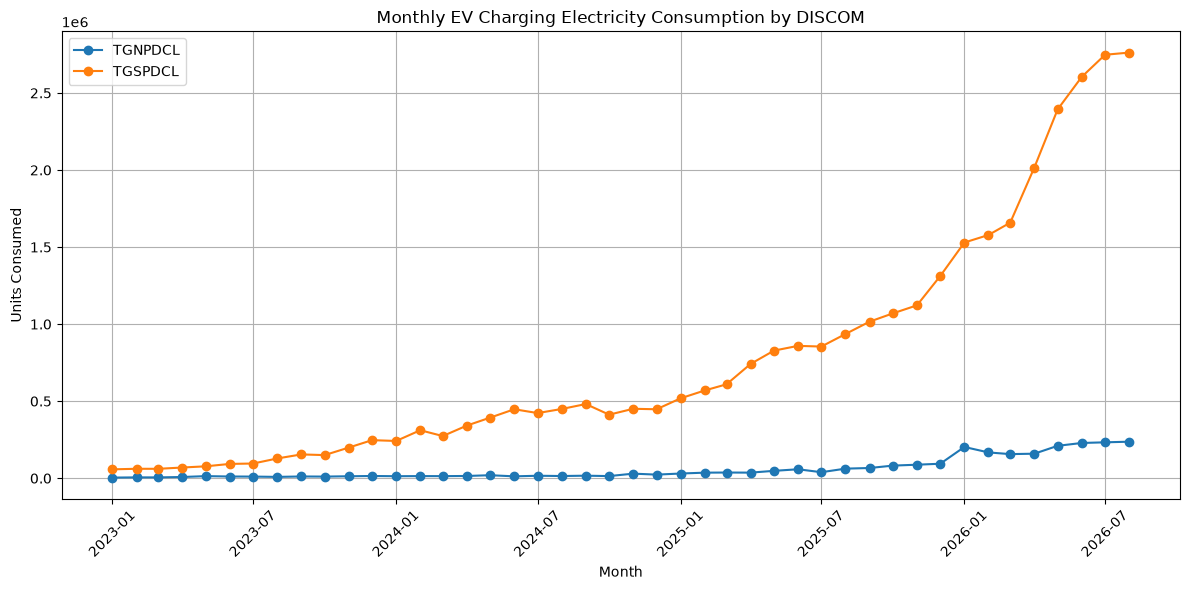

In [45]:
# Viz --- 2 
plt.figure(figsize=(12,6))

for discom in monthly_discom['discom'].unique():
    data=monthly_discom[monthly_discom['discom']==discom]

    plt.plot(data['date'],data['units'],marker="o",label=discom)
plt.title("Monthly EV Charging Electricity Consumption by DISCOM")
plt.xlabel("Month")
plt.ylabel("Units Consumed")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


##### Finding : 
1. "The overall increase in Telangana EV charging electricity consumption is driven predominantly by TGSPDCL, while TGNPDCL shows a smaller but generally increasing trend".
2. "Both DISCOMs show overall growth, but TGSPDCL operates at a substantially higher consumption level throughout the study period".


***
##### Average consumption per service
***

In [46]:
monthly_discom_summary = (df_final_combined.groupby(["date", "discom"]).agg(total_units=("units", "sum"),total_services=("totservices", "sum"),
billed_services=("billedservices", "sum")).reset_index())
monthly_discom_summary['units_per_service']=(
    monthly_discom_summary['total_units']/monthly_discom_summary['total_services']
)
monthly_discom_summary

,date,discom,total_units,total_services,billed_services,units_per_service
0,2023-01-01,TGNPDCL,4140.0,26,24.0,159.230769
1,2023-01-01,TGSPDCL,57704.0,95,89.0,607.410526
2,2023-02-01,TGNPDCL,5507.0,29,26.0,189.896552
3,2023-02-01,TGSPDCL,61355.0,97,92.0,632.525773
4,2023-03-01,TGNPDCL,5393.0,29,29.0,185.965517
...,...,...,...,...,...,...
83,2026-06-01,TGSPDCL,2604471.0,695,661.0,3747.440288
84,2026-07-01,TGNPDCL,233030.0,215,211.0,1083.860465
85,2026-07-01,TGSPDCL,2748044.0,709,683.0,3875.943583
86,2026-08-01,TGNPDCL,237108.0,215,215.0,1102.827907


In [47]:
monthly_discom_summary.groupby("discom")[ ["total_units", "total_services", "billed_services", "units_per_service"]].mean()

,total_units,total_services,billed_services,units_per_service
discom,,,,
TGNPDCL,58884.500000,87.272727,84.022727,513.949555
TGSPDCL,768114.886364,374.022727,355.477273,1642.592216


##### FInding : "The monthly aggregate consumption per recorded service averaged 513.95 units for TGNPDCL and 1,642.59 units for TGSPDCL over the study period."

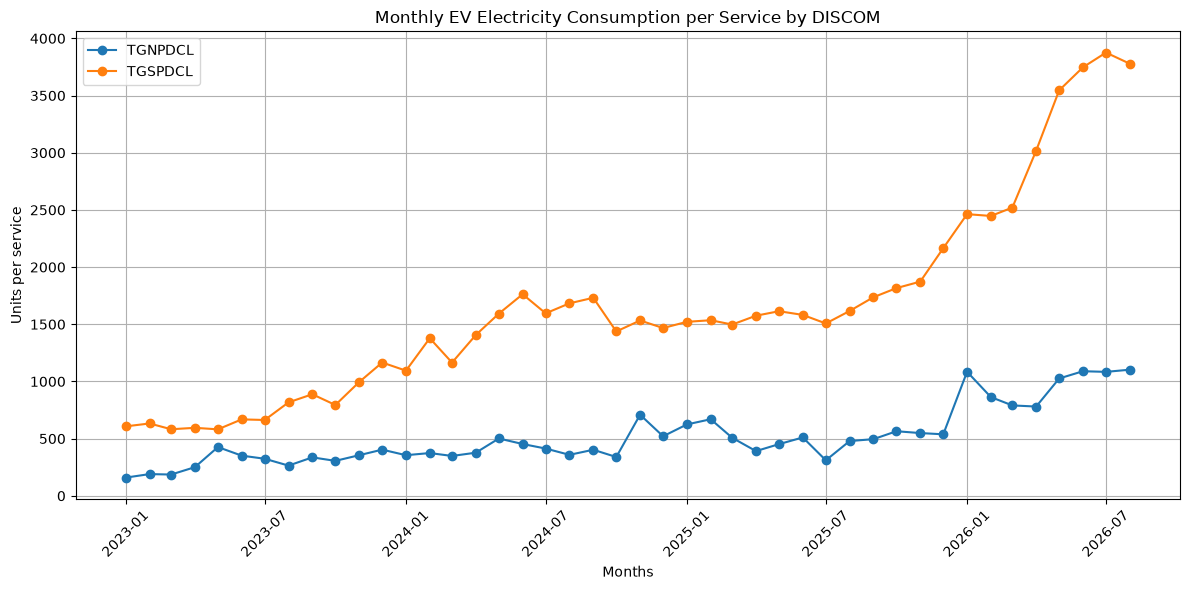

In [48]:
# Viz ----- 3 
plt.figure(figsize=(12,6))

for discom in monthly_discom_summary['discom'].unique():
    data=monthly_discom_summary[monthly_discom_summary['discom']==discom]

    plt.plot(data['date'],data['units_per_service'],marker="o",label=discom)


plt.title("Monthly EV Electricity Consumption per Service by DISCOM")
plt.xlabel("Months")
plt.ylabel("Units per service")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


***
 How quickly is the number of EV charging services growing in each DISCOM?
 ***

In [49]:
monthly_services=df_final_combined.groupby(['date','discom'],as_index=False).agg(total_services=("totservices","sum"), billed_services=("billedservices","sum")).sort_values(['date','discom'])

monthly_services

,date,discom,total_services,billed_services
0,2023-01-01,TGNPDCL,26,24.0
1,2023-01-01,TGSPDCL,95,89.0
2,2023-02-01,TGNPDCL,29,26.0
3,2023-02-01,TGSPDCL,97,92.0
4,2023-03-01,TGNPDCL,29,29.0
...,...,...,...,...
83,2026-06-01,TGSPDCL,695,661.0
84,2026-07-01,TGNPDCL,215,211.0
85,2026-07-01,TGSPDCL,709,683.0
86,2026-08-01,TGNPDCL,215,215.0


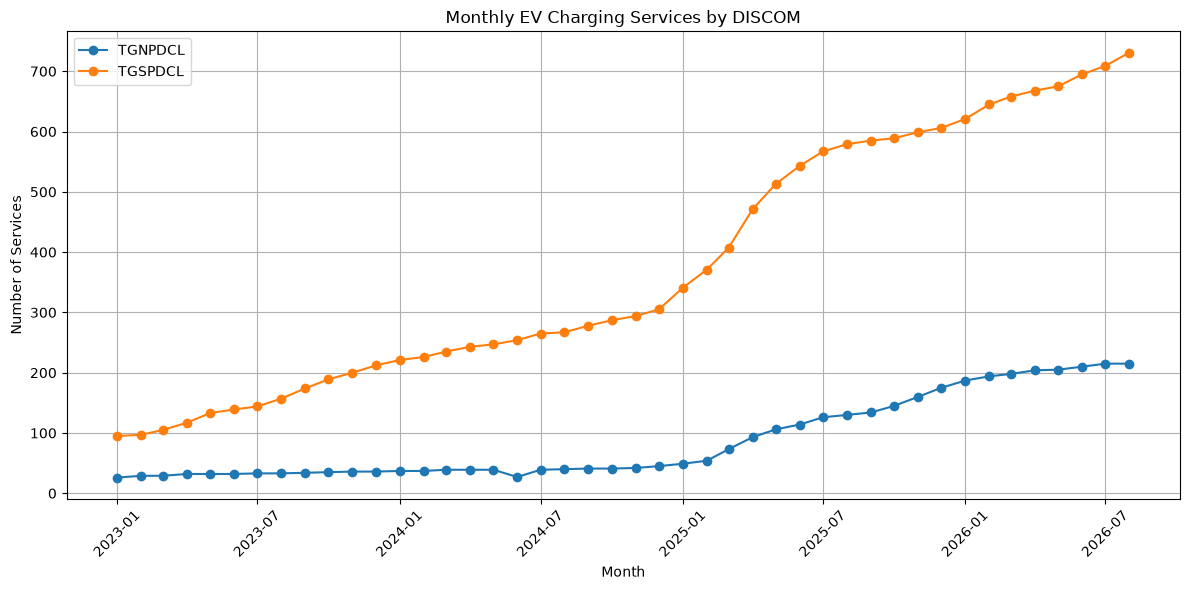

In [50]:
plt.figure(figsize=(12,6))

for discom in monthly_services['discom'].unique():
    data=monthly_services[monthly_services['discom']==discom]

    plt.plot(data['date'],data['total_services'],marker="o",label=discom)
plt.title("Monthly EV Charging Services by DISCOM")
plt.xlabel("Month")
plt.ylabel("Number of Services")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

>1.TGSPDCL: ~95 services/month in Jan 2023 → 731 in Aug 2026   
>      2.TGNPDCL: ~26 services/month in Jan 2023 → 215 in Aug 2026

So both DISCOMs show substantial growth in recorded services.

***
Which circles recorded the highest total EV charging electricity consumption during Jan 2023–Aug 2026?
***

In [51]:
circle_units=df_final_combined.groupby(['discom','circle'],as_index=False)['units'].sum().sort_values("units", ascending=False)
circle_units

,discom,circle,units
19,TGSPDCL,CYBERCITY,6998993.0
31,TGSPDCL,SAROORNAGAR,3918387.0
18,TGSPDCL,BANJARA HILLS,3547892.0
32,TGSPDCL,SECUNDERABAD,3325956.0
21,TGSPDCL,HABSIGUDA,2967571.0
26,TGSPDCL,MEDCHAL,2879339.0
22,TGSPDCL,HYDERABAD CENTRAL,2852523.0
29,TGSPDCL,RAJENDRA NAGAR,1523376.0
30,TGSPDCL,SANGAREDDY,1038648.0
23,TGSPDCL,HYDERABAD SOUTH,846641.0


In [52]:
# TGNPDCL top circles
print("North Side Top Circles",circle_units[circle_units['discom']=='TGNPDCL'])
print("SOuth Side Top Circles",circle_units[circle_units['discom']=='TGSPDCL'])



North Side Top Circles      discom                circle     units
4   TGNPDCL           HANUMAKONDA  554554.0
14  TGNPDCL             NIZAMABAD  500753.0
9   TGNPDCL               KHAMMAM  360901.0
8   TGNPDCL            KARIMNAGAR  241053.0
7   TGNPDCL             KAMAREDDY  197671.0
17  TGNPDCL              WARANGAL  124840.0
2   TGNPDCL  BHADRADRI KOTHAGUDEM  110484.0
13  TGNPDCL                NIRMAL  106118.0
15  TGNPDCL            PEDDAPALLY   92846.0
0   TGNPDCL              ADILABAD   91068.0
10  TGNPDCL           MAHABUBABAD   70325.0
11  TGNPDCL            MANCHERIAL   44325.0
6   TGNPDCL               JANGAON   38684.0
5   TGNPDCL              JAGITYAL   30804.0
16  TGNPDCL     RAJANNA SIRICILLA   13044.0
1   TGNPDCL              ASIFABAD    9476.0
3   TGNPDCL          BHUPALAPALLY    2300.0
12  TGNPDCL                MULUGU    1672.0
SOuth Side Top Circles      discom             circle      units
19  TGSPDCL          CYBERCITY  6998993.0
31  TGSPDCL        SAROORNAGAR  39

What percentage of each DISCOM's total EV electricity consumption comes from each circle?

In [53]:
circle_share=circle_units.copy()

circle_share["discom_total_units"] = (
    circle_units.groupby(['discom'])['units'].transform("sum")
)

circle_share['share_percentage']=(circle_share['units']/circle_share['discom_total_units']*100)

circle_share=circle_share.sort_values(['discom','share_percentage'],ascending=[True, False])

circle_share

,discom,circle,units,discom_total_units,share_percentage
4,TGNPDCL,HANUMAKONDA,554554.0,2590918.0,21.403765
14,TGNPDCL,NIZAMABAD,500753.0,2590918.0,19.327242
9,TGNPDCL,KHAMMAM,360901.0,2590918.0,13.929464
8,TGNPDCL,KARIMNAGAR,241053.0,2590918.0,9.303768
7,TGNPDCL,KAMAREDDY,197671.0,2590918.0,7.629381
17,TGNPDCL,WARANGAL,124840.0,2590918.0,4.818369
2,TGNPDCL,BHADRADRI KOTHAGUDEM,110484.0,2590918.0,4.264280
13,TGNPDCL,NIRMAL,106118.0,2590918.0,4.095768
15,TGNPDCL,PEDDAPALLY,92846.0,2590918.0,3.583518
0,TGNPDCL,ADILABAD,91068.0,2590918.0,3.514893


Finding : EV electricity consumption in Telangana is geographically concentrated across a relatively small number of electricity-distribution circles. During January 2023–August 2026, TGNPDCL recorded 2.59 million units, with its top five circles contributing 71.6% of consumption. TGSPDCL recorded 33.80 million units, with its top five circles contributing 61.4%. Hanumakonda was the leading TGNPDCL circle, while Cybercity was the leading TGSPDCL circle. Although TGSPDCL had substantially higher overall consumption, TGNPDCL showed greater concentration among its leading circles.

***
Are the circles consuming the most electricity also the circles with the most EV services?
***

In [54]:
circle_summary=df_final_combined.groupby(['discom','circle'],as_index=False).agg(total_units=("units", "sum"),total_services=("totservices", "sum"),billed_services=("billedservices", "sum"))
circle_summary['units_per_service']= (circle_summary["total_units"]/circle_summary['total_services'])
circle_summary['billing_rate']=(circle_summary['billed_services']/circle_summary['total_services'] * 100)

circle_summary=circle_summary.sort_values(["discom", "total_units"],ascending=[True, False])





In [55]:
circle_summary

,discom,circle,total_units,total_services,billed_services,units_per_service,billing_rate
4,TGNPDCL,HANUMAKONDA,554554.0,627,617.0,884.456140,98.405104
14,TGNPDCL,NIZAMABAD,500753.0,610,582.0,820.906557,95.409836
9,TGNPDCL,KHAMMAM,360901.0,202,195.0,1786.638614,96.534653
8,TGNPDCL,KARIMNAGAR,241053.0,319,309.0,755.652038,96.865204
7,TGNPDCL,KAMAREDDY,197671.0,397,372.0,497.911839,93.702771
17,TGNPDCL,WARANGAL,124840.0,137,134.0,911.240876,97.810219
2,TGNPDCL,BHADRADRI KOTHAGUDEM,110484.0,283,276.0,390.402827,97.526502
13,TGNPDCL,NIRMAL,106118.0,185,179.0,573.610811,96.756757
15,TGNPDCL,PEDDAPALLY,92846.0,233,224.0,398.480687,96.137339
0,TGNPDCL,ADILABAD,91068.0,189,185.0,481.841270,97.883598


Finding : Circle-level analysis shows that total EV electricity consumption is influenced by both the number of recorded services and the aggregate electricity consumption per service. In TGNPDCL, Hanumakonda had the highest total consumption with 554,554 units and 627 services, while Khammam recorded 1,786.64 units per service despite having only 202 services. In TGSPDCL, Cybercity was the leading circle with 6.999 million units and the highest units-per-service value among the major circles at 4,341.81, while Hyderabad Central recorded 2.85 million units from only 704 services, with 4,051.88 units per service. This indicates that high total consumption cannot be explained solely by the number of recorded services.

***
Top circles by consumption intensity -- (I am using 100 total services as the minimum.)
***

In [56]:
intensity_summary=circle_summary[circle_summary['total_services']>=100].copy()

intensity_summary=intensity_summary.sort_values(['units_per_service'],ascending=False)

print("North:",intensity_summary[intensity_summary['discom']=='TGNPDCL'])
print("South:",intensity_summary[intensity_summary['discom']=='TGSPDCL'])

North:      discom                circle  total_units  total_services  \
9   TGNPDCL               KHAMMAM     360901.0             202   
17  TGNPDCL              WARANGAL     124840.0             137   
4   TGNPDCL           HANUMAKONDA     554554.0             627   
14  TGNPDCL             NIZAMABAD     500753.0             610   
8   TGNPDCL            KARIMNAGAR     241053.0             319   
10  TGNPDCL           MAHABUBABAD      70325.0             106   
13  TGNPDCL                NIRMAL     106118.0             185   
7   TGNPDCL             KAMAREDDY     197671.0             397   
0   TGNPDCL              ADILABAD      91068.0             189   
15  TGNPDCL            PEDDAPALLY      92846.0             233   
2   TGNPDCL  BHADRADRI KOTHAGUDEM     110484.0             283   
6   TGNPDCL               JANGAON      38684.0             132   
11  TGNPDCL            MANCHERIAL      44325.0             197   

    billed_services  units_per_service  billing_rate  
9            

In [57]:
intensity_summary[intensity_summary['discom']=='TGNPDCL']


,discom,circle,total_units,total_services,billed_services,units_per_service,billing_rate
9,TGNPDCL,KHAMMAM,360901.0,202,195.0,1786.638614,96.534653
17,TGNPDCL,WARANGAL,124840.0,137,134.0,911.240876,97.810219
4,TGNPDCL,HANUMAKONDA,554554.0,627,617.0,884.456140,98.405104
14,TGNPDCL,NIZAMABAD,500753.0,610,582.0,820.906557,95.409836
8,TGNPDCL,KARIMNAGAR,241053.0,319,309.0,755.652038,96.865204
10,TGNPDCL,MAHABUBABAD,70325.0,106,102.0,663.443396,96.226415
13,TGNPDCL,NIRMAL,106118.0,185,179.0,573.610811,96.756757
7,TGNPDCL,KAMAREDDY,197671.0,397,372.0,497.911839,93.702771
0,TGNPDCL,ADILABAD,91068.0,189,185.0,481.841270,97.883598
15,TGNPDCL,PEDDAPALLY,92846.0,233,224.0,398.480687,96.137339


In [58]:
intensity_summary[intensity_summary['discom']=='TGSPDCL']

,discom,circle,total_units,total_services,billed_services,units_per_service,billing_rate
19,TGSPDCL,CYBERCITY,6998993.0,1612,1527.0,4341.807072,94.727047
22,TGSPDCL,HYDERABAD CENTRAL,2852523.0,704,686.0,4051.879261,97.443182
18,TGSPDCL,BANJARA HILLS,3547892.0,968,885.0,3665.177686,91.425620
32,TGSPDCL,SECUNDERABAD,3325956.0,1200,1147.0,2771.630000,95.583333
31,TGSPDCL,SAROORNAGAR,3918387.0,1719,1655.0,2279.457243,96.276905
26,TGSPDCL,MEDCHAL,2879339.0,1507,1405.0,1910.642999,93.231586
23,TGSPDCL,HYDERABAD SOUTH,846641.0,538,523.0,1573.682156,97.211896
21,TGSPDCL,HABSIGUDA,2967571.0,1902,1779.0,1560.237119,93.533123
29,TGSPDCL,RAJENDRA NAGAR,1523376.0,1020,988.0,1493.505882,96.862745
27,TGSPDCL,NAGARKURNOOL,277003.0,190,177.0,1457.910526,93.157895


Finding : After applying a minimum threshold of 100 recorded services, significant differences in consumption intensity were observed across circles. Khammam was the highest-intensity TGNPDCL circle at 1,786.64 units per recorded service. In TGSPDCL, Cybercity recorded the highest intensity at 4,341.81 units per service, followed by Hyderabad Central at 4,051.88 and Banjara Hills at 3,665.18. The highest-intensity TGSPDCL circle therefore recorded approximately 2.4 times the aggregate units per service of the highest-intensity TGNPDCL circle. The results demonstrate that total electricity consumption is influenced not only by the number of recorded services but also by the aggregate consumption associated with those services.

***
How did EV electricity consumption change year by year for TGNPDCL and TGSPDCL?
***

In [59]:
annual_discom=(df_final_combined.groupby(['discom','year'],as_index=False)).agg(total_units=('units',"sum"),total_services=('totservices',"sum")).sort_values(['discom','year'])
annual_discom['yoy_growth_percentage']=annual_discom.groupby('discom')['total_units'].pct_change()*100

annual_discom

,discom,year,total_units,total_services,yoy_growth_percentage
0,TGNPDCL,2023,116767.0,387,NaN
1,TGNPDCL,2024,201104.0,466,72.226742
2,TGNPDCL,2025,677735.0,1359,237.007220
3,TGNPDCL,2026,1595312.0,1628,135.388758
4,TGSPDCL,2023,1394349.0,1762,NaN
5,TGSPDCL,2024,4674429.0,3122,235.240962
6,TGSPDCL,2025,10437399.0,6171,123.287144
7,TGSPDCL,2026,17290878.0,5402,65.662710


In [60]:
jan_aug = df_final_combined[
    df_final_combined["month"] <= 8
]

jan_aug_discom = (
    jan_aug
    .groupby(["year", "discom"], as_index=False)
    .agg(
        total_units=("units", "sum"),
        total_services=("totservices", "sum")
    )
    .sort_values(["discom", "year"])
)

jan_aug_discom["growth_percent"] = (
    jan_aug_discom
    .groupby("discom")["total_units"]
    .pct_change() * 100
)

jan_aug_discom

,year,discom,total_units,total_services,growth_percent
0,2023,TGNPDCL,67334.0,246,NaN
2,2024,TGNPDCL,117487.0,297,74.483916
4,2025,TGNPDCL,347581.0,745,195.846349
6,2026,TGNPDCL,1595312.0,1628,358.975606
1,2023,TGSPDCL,643700.0,987,NaN
3,2024,TGSPDCL,2882343.0,1958,347.777381
5,2025,TGSPDCL,5917200.0,3792,105.291320
7,2026,TGSPDCL,17290878.0,5402,192.213851


Finding :  Year-over-year analysis shows substantial growth in EV charging electricity consumption across both Telangana DISCOMs. TGNPDCL increased by 72.23% in 2024 and 237.01% in 2025, indicating accelerating growth. TGSPDCL recorded even stronger growth of 235.24% in 2024, followed by 123.29% in 2025. For 2026, because only January–August data are available, a like-for-like comparison was used: Jan–Aug 2026 consumption increased by 358.98% for TGNPDCL and 192.21% for TGSPDCL compared with Jan–Aug 2025. Although TGNPDCL showed the higher percentage growth in the latest comparable period, TGSPDCL maintained a much larger absolute consumption base.

***
Are some months consistently associated with higher or lower EV electricity consumption?
***

In [61]:
monthly_year = (df_final_combined.groupby(["discom","year", "month"], as_index=False)["units"].sum()
)
monthly_year['year_totals'] = monthly_year.groupby(['year','discom'])['units'].transform('sum')

monthly_year['share_of_year_percent']=monthly_year['units']/monthly_year['year_totals']*100

monthly_year

,discom,year,month,units,year_totals,share_of_year_percent
0,TGNPDCL,2023,1,4140.0,116767.0,3.545522
1,TGNPDCL,2023,2,5507.0,116767.0,4.716230
2,TGNPDCL,2023,3,5393.0,116767.0,4.618599
3,TGNPDCL,2023,4,8015.0,116767.0,6.864097
4,TGNPDCL,2023,5,13637.0,116767.0,11.678813
...,...,...,...,...,...,...
83,TGSPDCL,2026,4,2016227.0,17290878.0,11.660640
84,TGSPDCL,2026,5,2393531.0,17290878.0,13.842738
85,TGSPDCL,2026,6,2604471.0,17290878.0,15.062688
86,TGSPDCL,2026,7,2748044.0,17290878.0,15.893028


In [62]:
seasonality_discom = (monthly_year.groupby(["discom", "month"], as_index=False)["share_of_year_percent"].mean()
)

In [63]:
seasonality_discom

,discom,month,share_of_year_percent
0,TGNPDCL,1,6.826448
1,TGNPDCL,2,6.856624
2,TGNPDCL,3,6.662905
3,TGNPDCL,4,7.380366
4,TGNPDCL,5,10.412776
5,TGNPDCL,6,9.657557
6,TGNPDCL,7,9.387384
7,TGNPDCL,8,9.658929
8,TGNPDCL,9,9.264029
9,TGNPDCL,10,9.384002


Finding : Calendar-month analysis revealed a broadly similar monthly consumption pattern across TGNPDCL and TGSPDCL. Both DISCOMs recorded relatively lower shares of consumption during January–March and higher shares during the later months of the year. TGNPDCL recorded its highest normalized monthly share in November (12.90%), followed by December (12.66%), while TGSPDCL recorded its highest share in December (13.29%), followed by November (11.55%) and August (10.94%). The similarity across both DISCOMs suggests a recurring calendar-month pattern in the recorded data; however, the available dataset does not contain sufficient explanatory variables to establish the underlying causes of this pattern.

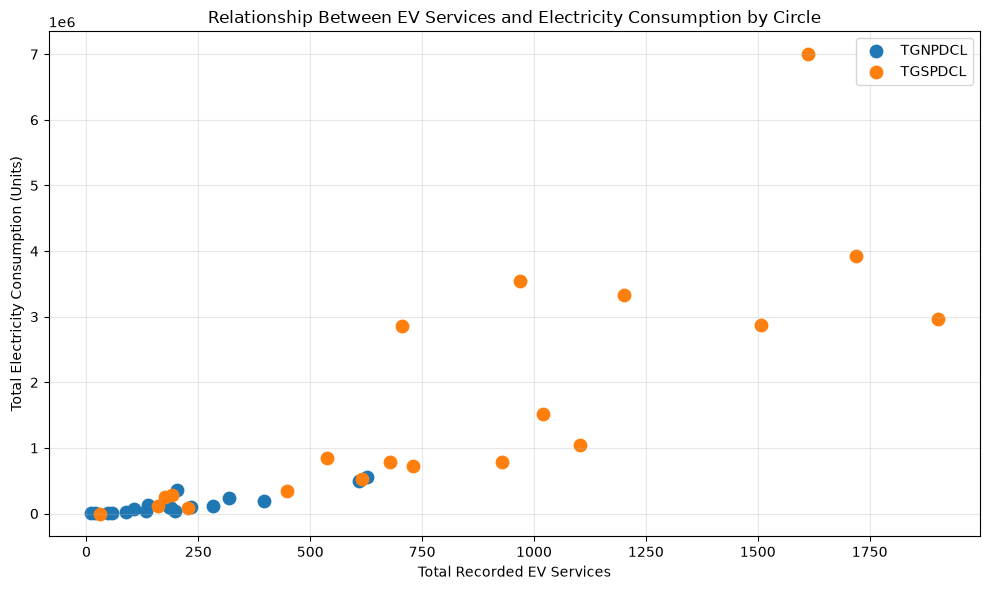

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for discom in circle_summary["discom"].unique():
    data = circle_summary[circle_summary["discom"] == discom]

    plt.scatter(data["total_services"],data["total_units"],label=discom,s=80)

plt.xlabel("Total Recorded EV Services")
plt.ylabel("Total Electricity Consumption (Units)")
plt.title("Relationship Between EV Services and Electricity Consumption by Circle")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
corr = (
    circle_summary
    .groupby("discom")
    .apply(
        lambda g: g["total_services"].corr(g["total_units"]),
        include_groups=False
    )
    .reset_index(name="pearson_correlation")
)

corr

,discom,pearson_correlation
0,TGNPDCL,0.896914
1,TGSPDCL,0.790639


In [66]:

from scipy.stats import pearsonr, spearmanr

results = []

for discom, data in circle_summary.groupby("discom"):

    pearson_r, pearson_p = pearsonr(
        data["total_services"],
        data["total_units"]
    )

    spearman_r, spearman_p = spearmanr(
        data["total_services"],
        data["total_units"]
    )

    results.append({
        "discom": discom,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

correlation_results = pd.DataFrame(results)

correlation_results

,discom,pearson_r,pearson_p,spearman_r,spearman_p
0,TGNPDCL,0.896914,4.619757e-07,0.898865,3.990237e-07
1,TGSPDCL,0.790639,3.335733e-05,0.911278,2.336013e-08


Finding : Both TGNPDCL and TGSPDCL show a strong positive association between recorded EV charging services and aggregate electricity consumption. TGNPDCL shows a strong linear relationship (Pearson r = 0.897), while TGSPDCL has a weaker linear association (Pearson r = 0.791) but an even stronger rank-based association (Spearman r = 0.911). All correlations are statistically significant at the 5% level. However, this analysis identifies association, not causation.

## 3. Business Questions

1. Is the reported load aligned with actual electricity consumption?

In [67]:
load_consumption=df_final_combined[["load","units"]].dropna()

load_consumption.corr()

,load,units
load,1.000000,0.469792
units,0.469792,1.000000


Pearson correlation: 0.4697921928020622
Pearson p_value: 0.0
Spearman coorelation: 0.21174531411107594
Spearman p_value: 6.062949114269248e-164


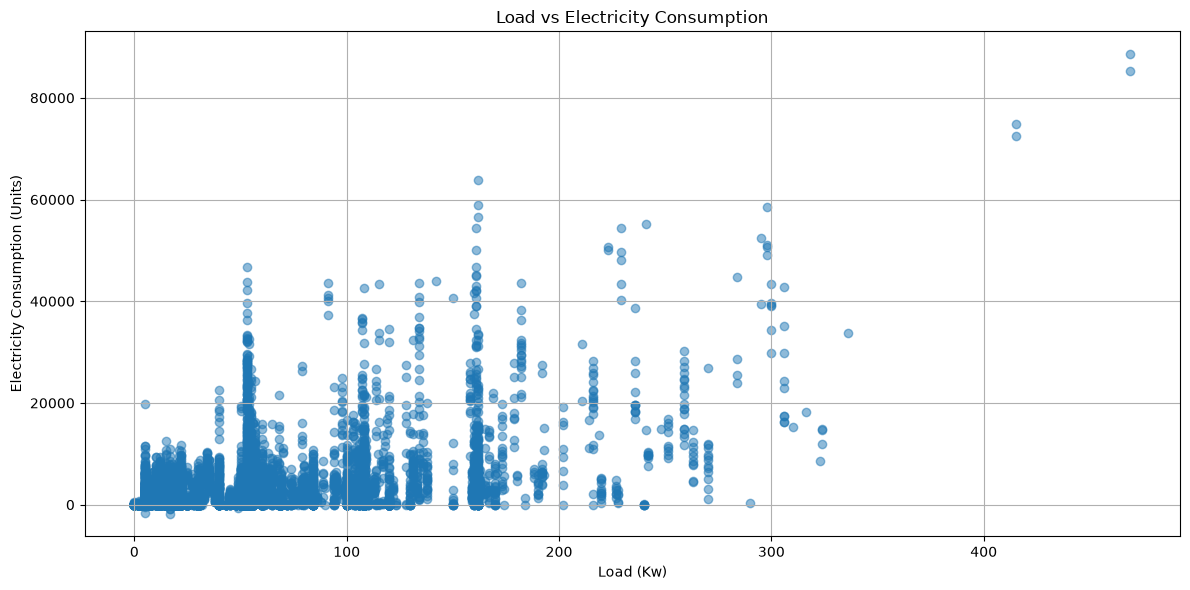

In [68]:
from scipy.stats import pearsonr,spearmanr 
data = df_final_combined[['load','units']].dropna()
pearson_r,pearson_p=pearsonr(
    data['load'],
    data['units']
)

spearman_r,spearman_p=spearmanr(
    data['load'],
    data['units']
)

print("Pearson correlation:",pearson_r)
print("Pearson p_value:",pearson_p)

print("Spearman coorelation:",spearman_r)
print("Spearman p_value:",spearman_p)



plt.figure(figsize=(12,6))
plt.scatter(data['load'],data['units'],alpha=0.5)

plt.xlabel("Load (Kw)")
plt.ylabel("Electricity Consumption (Units)")
plt.title("Load vs Electricity Consumption")
plt.grid(True)
plt.tight_layout()
plt.show()

Which locations have unusually high or low electricity consumption relative to their reported load?

In [69]:
df_final_combined['unit_per_load']=(df_final_combined['units']/df_final_combined['load'])

df_final_combined['unit_per_load'].describe()

df_final_combined[
    ["discom", "circle", "division", "section", "area",
     "load", "units", "unit_per_load"]
].sort_values(
    "unit_per_load",
    ascending=False
).head(20)

df_final_combined[
    ["discom", "circle", "division", "section", "area",
     "load", "units", "unit_per_load"]
].sort_values(
    "unit_per_load",
    ascending=True
).head(20)

,discom,circle,division,section,area,load,units,unit_per_load
9222,TGSPDCL,CYBERCITY,KONDAPUR,BALAJI NAGAR,MOOSAPET,5.0,-1548.0,-309.600000
6591,TGSPDCL,HYDERABAD CENTRAL,AZAMABAD,GOLNAKA,MARUTHI NAGAR,17.0,-1740.0,-102.352941
4341,TGSPDCL,RAJENDRA NAGAR,RAJENDRA NAGAR,MD PALLY,VINAYAK NAGAR,5.0,-462.0,-92.400000
4034,TGSPDCL,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAGH,POKALWADA,5.0,-323.0,-64.600000
4311,TGSPDCL,HYDERABAD CENTRAL,AZAMABAD,GOLNAKA,MARUTHI NAGAR,17.0,-867.0,-51.000000
4420,TGSPDCL,HYDERABAD CENTRAL,AZAMABAD,GOLNAKA,MARUTHI NAGAR,17.0,-851.0,-50.058824
4266,TGSPDCL,SECUNDERABAD,BOWENPALLY,I.D.P.L.,PRASHANTH NAGAR CLY (GRP-B),4.0,-150.0,-37.500000
7036,TGSPDCL,HYDERABAD SOUTH,CHARMINAR,KISHANBAGH,BHARATH NAGAR,5.0,-107.0,-21.400000
4486,TGSPDCL,SECUNDERABAD,PARADISE,TARNAKA,GOKUL NAGAR,5.0,-102.0,-20.400000
7158,TGSPDCL,SECUNDERABAD,BOWENPALLY,RANGA REDDY NAGAR,ASBESTOS CLY-II 415-812(GRP-B),2.0,-38.0,-19.000000


In [70]:
load_analysis=df_final_combined[df_final_combined['units']>=0].copy()
area_load_summary=(load_analysis.groupby(['discom','circle','division','subdivision','section','area'],as_index=False)).agg(total_units=("units","sum"),total_load=("load","sum"),total_services=('totservices','sum'),months_observed=("date","nunique"))
area_load_summary['unit_per_reported_load']=(
    area_load_summary['total_units']/area_load_summary['total_load']
)

In [71]:
area_load_summary[
    ["total_units", "total_load", "total_services","months_observed", "unit_per_reported_load"]
].describe()

,total_units,total_load,total_services,months_observed,unit_per_reported_load
count,843.000000,843.000000,843.000000,843.000000,843.000000
mean,43172.996441,984.422456,24.060498,19.241993,49.281736
std,80693.812069,908.055270,20.188539,12.670061,116.684240
min,0.000000,0.972000,1.000000,1.000000,0.000000
25%,471.000000,349.000000,10.000000,9.000000,0.938054
50%,10749.000000,810.000000,18.000000,17.000000,14.806134
75%,48473.500000,1260.000000,35.000000,27.000000,53.060937
max,585007.000000,7790.000000,140.000000,44.000000,2200.617284


In [72]:
area_load_summary.sort_values(['unit_per_reported_load'],ascending=False).head(30)

,discom,circle,division,subdivision,section,area,total_units,total_load,total_services,months_observed,unit_per_reported_load
133,TGNPDCL,NIRMAL,BHAINSA,BASAR,BASAR,BASAR,2139.0,0.972,18,18,2200.617284
293,TGSPDCL,CYBERCITY,KONDAPUR,KPHB,BALAJI NAGAR,MOOSAPET,227573.0,200.000,40,40,1137.865000
669,TGSPDCL,SAROORNAGAR,CHAMPAPET,CHAMPAPET,CHAMPAPET,SRINIVASACOLONY(L),81073.0,110.000,22,22,737.027273
403,TGSPDCL,HYDERABAD SOUTH,ASMANGADH,CHANCHALGUDA,CHANCHALGUDA,TOTAL HV SERVICES,49669.0,72.000,6,6,689.847222
253,TGSPDCL,CYBERCITY,GACHIBOWLI,GACHIBOWLI,GACHIBOWLI,JOURNALIST COLONY,71270.0,110.000,22,22,647.909091
290,TGSPDCL,CYBERCITY,KONDAPUR,KONDAPUR,WHITE FIELD,SRIRAM NAGAR & JVG CT METERS,203687.0,371.000,7,7,549.021563
595,TGSPDCL,RAJENDRA NAGAR,RAJENDRA NAGAR,GAGANPAHAD,MD PALLY,URRAM GADDA,130547.0,260.000,52,43,502.103846
596,TGSPDCL,RAJENDRA NAGAR,RAJENDRA NAGAR,GAGANPAHAD,MD PALLY,VINAYAK NAGAR,32482.0,65.000,13,13,499.723077
269,TGSPDCL,CYBERCITY,IBRAHIMBAGH,IBRAHIMBAG,IBRAHIMBAGH,SHIVALAYAM,160851.0,371.000,7,7,433.560647
228,TGSPDCL,CYBERCITY,GACHIBOWLI,CHANDA NAGAR,CHANDA NAGAR,"ADITYA,PRAKASH NAGAR",83698.0,200.000,10,10,418.490000


In [73]:
area_load_summary.sort_values(['unit_per_reported_load'],ascending=True).head(30)


,discom,circle,division,subdivision,section,area,total_units,total_load,total_services,months_observed,unit_per_reported_load
811,TGSPDCL,VIKARABAD,VIKARABAD,VIKARABAD,MANNEGUDA,GANGU PALLY,0.0,108.000,2,2,0.0
81,TGNPDCL,KAMAREDDY,YELLAREDDY,YELLAREDDY,YELLAREDDY,YELLAREDDY,0.0,300.000,10,10,0.0
77,TGNPDCL,KAMAREDDY,KAMAREDDY,Kamareddy Town,KAMAREDDY TOWN-III,DEVANPALLY (A),0.0,150.240,13,13,0.0
76,TGNPDCL,KAMAREDDY,KAMAREDDY,Kamareddy Town,KAMAREDDY TOWN-II,A2,0.0,702.000,13,13,0.0
714,TGSPDCL,SAROORNAGAR,SAROORNAGAR,HAYATHNAGAR,PEDDA AMBERPET,SAI COLONY RD 1 2 3 4 5 & 6,0.0,108.000,2,2,0.0
713,TGSPDCL,SAROORNAGAR,SAROORNAGAR,HAYATHNAGAR,PEDDA AMBERPET,SAI COLONY PHASE III,0.0,540.000,10,10,0.0
66,TGNPDCL,KAMAREDDY,BANSWADA,BICHKUNDA,BICHKUNDA,KANDARPALLI,0.0,600.000,5,5,0.0
600,TGSPDCL,RAJENDRA NAGAR,RAJENDRA NAGAR,RAJENDRANAGAR,HIMAYAT SAGAR,CT METERS HIMAYATHSAGAR,0.0,162.000,3,3,0.0
89,TGNPDCL,KARIMNAGAR,KARIMNAGAR,Karimnagar Town,KRN TOWN 1,DOCTOR STREET,0.0,702.054,14,14,0.0
101,TGNPDCL,KHAMMAM,KHAMMAM,RAGUNADAPALEM,MANCHUKONDA,MANCHUKONDA,0.0,180.000,6,6,0.0


In [74]:
area_load_summary["months_observed"].value_counts().sort_index()

months_observed
1     24
2     24
3     25
4     23
5     25
6     19
7     34
8     28
9     15
10    26
11    18
12    11
13    24
14    29
15    29
16    42
17    57
18    40
19    24
20    31
21    22
22    18
23    16
24    10
25     6
26    10
27     6
28     5
29     6
30     6
31    12
32     8
33    10
34    10
35    14
36    12
37    10
38     7
39     5
40    13
41     8
42     6
43    17
44    58
Name: count, dtype: int64

In [75]:
area_load_12m = area_load_summary[
    area_load_summary["months_observed"] >= 12
].copy()

print(area_load_12m.shape)

area_load_12m["months_observed"].describe()

(582, 11)


count    582.000000
mean      25.237113
std       10.588150
min       12.000000
25%       17.000000
50%       21.000000
75%       35.000000
max       44.000000
Name: months_observed, dtype: float64

In [76]:
area_load_12m[
    ["total_units", "total_load", "total_services"]
].describe()

area_load_12m["consumption_percentile"] = (
    area_load_12m["total_units"]
    .rank(pct=True)
)

area_load_12m["load_percentile"] = (
    area_load_12m["total_load"]
    .rank(pct=True)
)

In [77]:
area_load_12m["demand_load_gap"] = (
    area_load_12m["consumption_percentile"]
    - area_load_12m["load_percentile"]
)

In [78]:
area_load_12m.sort_values(
    "demand_load_gap",
    ascending=False
)[["discom","circle","division","subdivision","section","area","total_units","total_load","total_services","months_observed","consumption_percentile","load_percentile","demand_load_gap" ]].head(20)

,discom,circle,division,subdivision,section,area,total_units,total_load,total_services,months_observed,consumption_percentile,load_percentile,demand_load_gap
293,TGSPDCL,CYBERCITY,KONDAPUR,KPHB,BALAJI NAGAR,MOOSAPET,227573.0,200.0,40,40,0.950172,0.060137,0.890034
595,TGSPDCL,RAJENDRA NAGAR,RAJENDRA NAGAR,GAGANPAHAD,MD PALLY,URRAM GADDA,130547.0,260.0,52,43,0.881443,0.082474,0.798969
384,TGSPDCL,HYDERABAD CENTRAL,MEHDIPATNAM,MEHDIPATNAM,SURYANAGAR,GRC HV SURYA NAGAR,184541.0,579.0,34,34,0.926117,0.171821,0.754296
756,TGSPDCL,SECUNDERABAD,PARADISE,PADMA RAO NAGAR,TARNAKA,GRC HV TARNAKA,128642.0,370.0,37,37,0.876289,0.123711,0.752577
369,TGSPDCL,HABSIGUDA,SAINIKPURI,SAINIKPURI,YAPRAL,MYTHRI ENCLAVE,119966.0,331.0,23,23,0.860825,0.109966,0.750859
669,TGSPDCL,SAROORNAGAR,CHAMPAPET,CHAMPAPET,CHAMPAPET,SRINIVASACOLONY(L),81073.0,110.0,22,22,0.773196,0.028351,0.744845
739,TGSPDCL,SECUNDERABAD,BOWENPALLY,BOWENPALLY,NEW BOWENPALLY,BORE-ST-GRC(AGL) (GRP-M),123049.0,375.0,25,25,0.865979,0.125430,0.740550
239,TGSPDCL,CYBERCITY,GACHIBOWLI,CHANDA NAGAR,VASANTH NAGAR,GOPALA NAGAR,165618.0,597.0,44,44,0.912371,0.176976,0.735395
253,TGSPDCL,CYBERCITY,GACHIBOWLI,GACHIBOWLI,GACHIBOWLI,JOURNALIST COLONY,71270.0,110.0,22,22,0.757732,0.028351,0.729381
487,TGSPDCL,MEDCHAL,KUKATPALLY,MIYAPUR,HYDERNAGAR,B K ENCLAVE,114869.0,382.0,30,30,0.852234,0.127148,0.725086


In [79]:
area_load_12m.sort_values(
    "demand_load_gap",
    ascending=True
)[
    [
        "discom",
        "circle",
        "division",
        "subdivision",
        "section",
        "area",
        "total_units",
        "total_load",
        "total_services",
        "months_observed",
        "consumption_percentile",
        "load_percentile",
        "demand_load_gap"
    ]
].head(20)

,discom,circle,division,subdivision,section,area,total_units,total_load,total_services,months_observed,consumption_percentile,load_percentile,demand_load_gap
413,TGSPDCL,HYDERABAD SOUTH,CHARMINAR,FALAKNUMA,CHANDRAYANA GUTTA,GRC,70.0,1944.000,36,18,0.076460,0.831615,-0.755155
211,TGSPDCL,BANJARA HILLS,BANJARA HILLS,JUBILEE HILLS,JUBILEE HILLS,HV ROAD 22 TO 35,154.0,1950.000,39,39,0.097079,0.837629,-0.740550
33,TGNPDCL,HANUMAKONDA,HANAMKONDA/TOWN,HANAMKONDA(T),MACHILIBAZAR,RANGAMPET,47.0,1802.053,35,19,0.068729,0.805842,-0.737113
769,TGSPDCL,SIDDIPET,GAJWEL,GAJWEL,GAJWEL,GAJWEL,1667.0,2160.000,40,20,0.199313,0.871134,-0.671821
838,TGSPDCL,YADADRI,CHOUTUPPAL,CHOUTUPPAL,CHOUTUPPAL,PANTHANGI,1417.0,1836.000,34,17,0.187285,0.811856,-0.624570
553,TGSPDCL,NALGONDA,NALGONDA,NAKREKAL,KATTANGUR,KATTANGUR,439.0,1674.000,31,17,0.146048,0.757732,-0.611684
289,TGSPDCL,CYBERCITY,KONDAPUR,KONDAPUR,WHITE FIELD,HV WHITEFIELD,1169.0,1768.000,34,34,0.182131,0.780069,-0.597938
693,TGSPDCL,SAROORNAGAR,IBRAHIMPATNAM,TURKAYAMJAL,ABDULLAPURMET,OUTER RING ROAD,1047.0,1512.000,28,20,0.180412,0.731100,-0.550687
331,TGSPDCL,HABSIGUDA,KEESARA,GHATKESAR,GHATKESAR,GHATKESAR,7806.0,2280.000,52,34,0.331615,0.881443,-0.549828
136,TGNPDCL,NIRMAL,NIRMAL,KHANAPUR,MAMDA,BOORGUPALLI,1916.0,1690.000,24,17,0.218213,0.766323,-0.548110


Area-level Growth Analysis

In [80]:
growth_area=load_analysis.copy()


growth_area['period']=growth_area['date'].apply(lambda x : "Jan-Aug 2025" if x.year==2025 and x.month <=8
else "Jan-Aug 2026" if x.year==2026 and x.month<=8 else None)

area_growth=growth_area.groupby(['discom','circle','division','subdivision','section','area','period'],as_index=False).agg(total_units=("units","sum"),months_observed=("date","nunique"))

area_growth_pivot=( area_growth.pivot_table(
    index=["discom","circle","division","subdivision","section","area"], columns='period',values=['total_units','months_observed'], fill_value=0

).reset_index())
area_growth_pivot

discom    circle    division    subdivision            section  \
period                                                                    
0       TGNPDCL  ADILABAD    ADILABAD  ADILABAD TOWN  ADILABAD TOWN-III   
1       TGNPDCL  ADILABAD    ADILABAD  ADILABAD TOWN             MAVALA   
2       TGNPDCL  ADILABAD    ADILABAD         ECHODA             ECHODA   
3       TGNPDCL  ADILABAD      UTNOOR         UTNOOR        GUDIHATNOOR   
4       TGNPDCL  ADILABAD      UTNOOR         UTNOOR        GUDIHATNOOR   
..          ...       ...         ...            ...                ...   
772     TGSPDCL   YADADRI  CHOUTUPPAL     CHOUTUPPAL         CHOUTUPPAL   
773     TGSPDCL   YADADRI  CHOUTUPPAL     CHOUTUPPAL         CHOUTUPPAL   
774     TGSPDCL   YADADRI  CHOUTUPPAL     CHOUTUPPAL         CHOUTUPPAL   
775     TGSPDCL   YADADRI  CHOUTUPPAL     RAMANNAPET         RAMANNAPET   
776     TGSPDCL   YADADRI  CHOUTUPPAL     RAMANNAPET         RAMANNAPET   

                     area months_observed               total_units  \
period                       Jan-Aug 2025 Jan-Aug 2026 Jan-Aug 2025   
0       ADILABAD-TOWN-III             8.0          8.0       8319.0   
1                DASNAPUR             8.0          8.0       2491.0   
2             ADEGAON (B)             0.0          8.0          0.0   
3                  MANNUR             0.0          8.0          0.0   
4            SEETHAGONDHI             0.0          8.0          0.0   
..                    ...             ...          ...          ...   
772             PANTHANGI             5.0          8.0          0.0   
773           TOOFRAN PET             6.0          8.0         20.0   
774             YELLAGIRI             0.0          2.0          0.0   
775              B. CYCLE             0.0          6.0          0.0   
776              BHOGARAM             0.0          6.0          0.0   

                     
period Jan-Aug 2026  
0           19114.0  
1           29521.0  
2             279.0  
3              98.0  
4            2654.0  
..              ...  
772          1417.0  
773         19574.0  
774             1.0  
775           210.0  
776           178.0  

[777 rows x 10 columns]

In [81]:
area_growth_pivot.columns

MultiIndex([(         'discom',             ''),
            (         'circle',             ''),
            (       'division',             ''),
            (    'subdivision',             ''),
            (        'section',             ''),
            (           'area',             ''),
            ('months_observed', 'Jan-Aug 2025'),
            ('months_observed', 'Jan-Aug 2026'),
            (    'total_units', 'Jan-Aug 2025'),
            (    'total_units', 'Jan-Aug 2026')],
           names=[None, 'period'])

In [82]:
area_growth_final=area_growth_pivot.copy()

area_growth_final['units_2026']=(area_growth_final[('total_units','Jan-Aug 2026')])
area_growth_final['units_2025']=(area_growth_final[('total_units','Jan-Aug 2025')])

area_growth_final['growth_units']=(area_growth_final['units_2026']-area_growth_final['units_2025'])

area_growth_final['growth_percent']=(
    area_growth_final['growth_units']/area_growth_final['units_2025'] * 100
)

In [83]:
area_growth_established = area_growth_final[(area_growth_final[("months_observed", "Jan-Aug 2025")] == 8) &(area_growth_final[("months_observed", "Jan-Aug 2026")] == 8) &(area_growth_final["units_2025"] > 0)
].copy()

print("Number of established areas:", len(area_growth_established))

area_growth_established[
        ["discom","circle","area","units_2025","units_2026","growth_units","growth_percent"]].sort_values("growth_percent", ascending=False).head(20)


Number of established areas: 260


,discom,circle,area,units_2025,units_2026,growth_units,growth_percent
period,,,,,,,
89,TGNPDCL,KARIMNAGAR,HOUSING BOARD,1.0,46366.0,46365.0,4.636500e+06
718,TGSPDCL,SIDDIPET,AE TOWN-1-HV,20.0,73632.0,73612.0,3.680600e+05
586,TGSPDCL,SANGAREDDY,ISNP HV-2,45.0,82512.0,82467.0,1.832600e+05
511,TGSPDCL,NALGONDA,SETTI PALEM,15.0,26207.0,26192.0,1.746133e+05
432,TGSPDCL,MEDCHAL,I D A,10.0,5533.0,5523.0,5.523000e+04
741,TGSPDCL,SURYAPET,UNDRUGONDA,23.0,10334.0,10311.0,4.483043e+04
427,TGSPDCL,MEDAK,MASAIPET,53.0,22678.0,22625.0,4.268868e+04
740,TGSPDCL,SURYAPET,DURAJPALLY,32.0,13484.0,13452.0,4.203750e+04
566,TGSPDCL,RAJENDRA NAGAR,CT METERS SDNR RURAL,302.0,34813.0,34511.0,1.142748e+04




Area-level analysis identifies several locations experiencing substantial growth in EV electricity consumption between Jan–Aug 2025 and Jan–Aug 2026. However, percentage growth alone is distorted by very small 2025 baselines. Therefore, absolute increase in consumption and current demand should be considered alongside growth percentage when identifying potential expansion or investment candidates.

In [84]:
area_growth_meaningful = area_growth_established[ area_growth_established["units_2025"] >= 1000
].copy()
area_growth_meaningful = (area_growth_meaningful.sort_values("growth_units", ascending=False)
)


area_growth_meaningful[
        [  "discom",  "circle",  "area",  "units_2025",  "units_2026",  "growth_units",  "growth_percent"]  ].head(20)


,discom,circle,area,units_2025,units_2026,growth_units,growth_percent
period,,,,,,,
236,TGSPDCL,CYBERCITY,HV GOWLI DODDI,34140.0,324838.0,290698.0,851.487991
217,TGSPDCL,BANJARA HILLS,CT METERS,82707.0,348692.0,265985.0,321.599139
680,TGSPDCL,SECUNDERABAD,C.T.METER GRC (GRP-M),93467.0,309977.0,216510.0,231.643254
694,TGSPDCL,SECUNDERABAD,C T METERS,112612.0,324342.0,211730.0,188.017263
195,TGSPDCL,BANJARA HILLS,HV ROAD NO 2 AND 3,9633.0,218311.0,208678.0,2166.282570
246,TGSPDCL,CYBERCITY,TARANAGAR GOVT,70925.0,268582.0,197657.0,278.684526
265,TGSPDCL,CYBERCITY,HV-3,82505.0,271815.0,189310.0,229.452760
682,TGSPDCL,SECUNDERABAD,CT METERS (GRP-M),29673.0,215759.0,186086.0,627.122300
701,TGSPDCL,SECUNDERABAD,HIGH VALVE-CT METERS (GRP-M),46813.0,201638.0,154825.0,330.730780


In [91]:
area_growth_clean = area_growth_meaningful[
    [ "discom", "circle", "division", "subdivision", "section", "area", "units_2025", "units_2026", "growth_units", "growth_percent"]].copy()
area_growth_clean.columns = [
    col[0] if col[1] == "" else col[0] + "_" + col[1].replace("-", "_").replace(" ", "_")
    if isinstance(col, tuple)
    else col
    for col in area_growth_clean.columns
]

In [93]:
area_combined = pd.merge(
    area_growth_clean,
    area_load_12m,
    on=[ "discom", "circle", "division", "subdivision", "section", "area"],
    how="inner"
)
print("Number of matching areas:", len(area_combined))

combined_candidates=area_combined[area_combined['demand_load_gap']>0] .copy()
combined_candidates=(combined_candidates.sort_values("growth_units",ascending=False))
print("Positive Gap Areas:", len(combined_candidates))

combined_candidates[['discom','circle','area','units_2025','units_2026','growth_units','growth_percent','total_load','total_services','demand_load_gap']].head(20)

Number of matching areas: 218
Positive Gap Areas: 111


,discom,circle,area,units_2025,units_2026,growth_units,growth_percent,total_load,total_services,demand_load_gap
0,TGSPDCL,CYBERCITY,HV GOWLI DODDI,34140.0,324838.0,290698.0,851.487991,2016.0,37,0.131443
1,TGSPDCL,BANJARA HILLS,CT METERS,82707.0,348692.0,265985.0,321.599139,4317.0,78,0.006873
2,TGSPDCL,SECUNDERABAD,C.T.METER GRC (GRP-M),93467.0,309977.0,216510.0,231.643254,4010.0,65,0.010309
3,TGSPDCL,SECUNDERABAD,C T METERS,112612.0,324342.0,211730.0,188.017263,4894.0,84,0.003436
4,TGSPDCL,BANJARA HILLS,HV ROAD NO 2 AND 3,9633.0,218311.0,208678.0,2166.282570,2586.0,48,0.049828
6,TGSPDCL,CYBERCITY,HV-3,82505.0,271815.0,189310.0,229.452760,2789.0,49,0.056701
7,TGSPDCL,SECUNDERABAD,CT METERS (GRP-M),29673.0,215759.0,186086.0,627.122300,1200.0,21,0.324742
9,TGSPDCL,BANJARA HILLS,KAVURI HILLS,57538.0,196303.0,138765.0,241.171052,2902.0,54,0.056701
10,TGSPDCL,BANJARA HILLS,CT METERS,38578.0,171422.0,132844.0,344.351703,1060.0,20,0.387457
11,TGSPDCL,CYBERCITY,MIYAPUR HV,42453.0,167894.0,125441.0,295.482063,3329.0,70,0.020619


In [94]:
growth_median = area_combined["growth_units"].median()
gap_median = area_combined["demand_load_gap"].median()

print("Median growth (units):", growth_median)
print("Median demand-load gap:", gap_median)


area_combined["priority_category"] = "Lower Immediate Priority"

area_combined.loc[
    (area_combined["growth_units"] > growth_median) &
    (area_combined["demand_load_gap"] > gap_median),
    "priority_category"
] = "Priority Investigation"

area_combined.loc[
    (area_combined["growth_units"] > growth_median) &
    (area_combined["demand_load_gap"] <= gap_median),
    "priority_category"
] = "Growth Opportunity"

area_combined.loc[
    (area_combined["growth_units"] <= growth_median) &
    (area_combined["demand_load_gap"] > gap_median),
    "priority_category"
] = "Load-Gap Review"

Median growth (units): 7119.0
Median demand-load gap: 0.005154639175257714


In [95]:
print(area_combined["priority_category"].value_counts())

priority_areas = area_combined[
    area_combined["priority_category"] == "Priority Investigation"
].copy()

priority_areas = priority_areas.sort_values(
    ["growth_units", "demand_load_gap"],
    ascending=False
)


priority_areas[    [ "discom","circle","area","units_2025","units_2026","growth_units","growth_percent","total_load","total_services","demand_load_gap"]].head(20)



priority_areas["growth_score"] = (
    priority_areas["growth_units"].rank(pct=True) * 100
)

priority_areas["gap_score"] = (
    priority_areas["demand_load_gap"].rank(pct=True) * 100
)

priority_areas['combined_score']=(priority_areas["growth_score"] * 0.5+ priority_areas["gap_score"] * 0.5)

priority_category
Priority Investigation      62
Lower Immediate Priority    62
Growth Opportunity          47
Load-Gap Review             47
Name: count, dtype: int64


In [96]:
priority_areas = priority_areas.sort_values(
    "combined_score",
    ascending=False
)


priority_areas[
        [ "discom", "circle", "area", "units_2025", "units_2026", "growth_units", "growth_percent", "total_load", "total_services", "demand_load_gap", "growth_score", "gap_score", "combined_score"
        ]].head(20)


,discom,circle,area,units_2025,units_2026,growth_units,growth_percent,total_load,total_services,demand_load_gap,growth_score,gap_score,combined_score
26,TGSPDCL,HABSIGUDA,OLD MOULALI,16850.0,69009.0,52159.0,309.548961,519.0,40,0.701031,74.193548,90.322581,82.258065
36,TGSPDCL,SECUNDERABAD,GRC HV TARNAKA,26977.0,62070.0,35093.0,130.084887,370.0,37,0.752577,64.516129,98.387097,81.451613
34,TGSPDCL,CYBERCITY,JOURNALIST COLONY,10795.0,47516.0,36721.0,340.166744,110.0,22,0.729381,67.741935,93.548387,80.645161
10,TGSPDCL,BANJARA HILLS,CT METERS,38578.0,171422.0,132844.0,344.351703,1060.0,20,0.387457,88.709677,70.967742,79.838710
7,TGSPDCL,SECUNDERABAD,CT METERS (GRP-M),29673.0,215759.0,186086.0,627.122300,1200.0,21,0.324742,91.935484,66.129032,79.032258
13,TGSPDCL,HABSIGUDA,R.K PURAM,17038.0,115926.0,98888.0,580.396760,1060.0,20,0.323883,85.483871,64.516129,75.000000
42,TGSPDCL,MEDCHAL,B K ENCLAVE,18421.0,50392.0,31971.0,173.557353,382.0,30,0.725086,58.064516,91.935484,75.000000
44,TGSPDCL,CYBERCITY,GOPALA NAGAR,35581.0,66881.0,31300.0,87.968298,597.0,44,0.735395,54.838710,95.161290,75.000000
0,TGSPDCL,CYBERCITY,HV GOWLI DODDI,34140.0,324838.0,290698.0,851.487991,2016.0,37,0.131443,100.000000,46.774194,73.387097
17,TGSPDCL,CYBERCITY,POKALWADA,99172.0,178482.0,79310.0,79.972170,1400.0,40,0.278351,83.870968,61.290323,72.580645


*** 
Validate the top priority areas using current consumption + services
***

In [97]:
top_priority=(
    priority_areas.sort_values("combined_score",ascending=False).head(20).copy()
)

top_priority[["discom","circle","area","units_2025","units_2026","growth_units","growth_percent","total_services","total_load","demand_load_gap","combined_score"
        ]]


,discom,circle,area,units_2025,units_2026,growth_units,growth_percent,total_services,total_load,demand_load_gap,combined_score
26,TGSPDCL,HABSIGUDA,OLD MOULALI,16850.0,69009.0,52159.0,309.548961,40,519.0,0.701031,82.258065
36,TGSPDCL,SECUNDERABAD,GRC HV TARNAKA,26977.0,62070.0,35093.0,130.084887,37,370.0,0.752577,81.451613
34,TGSPDCL,CYBERCITY,JOURNALIST COLONY,10795.0,47516.0,36721.0,340.166744,22,110.0,0.729381,80.645161
10,TGSPDCL,BANJARA HILLS,CT METERS,38578.0,171422.0,132844.0,344.351703,20,1060.0,0.387457,79.838710
7,TGSPDCL,SECUNDERABAD,CT METERS (GRP-M),29673.0,215759.0,186086.0,627.122300,21,1200.0,0.324742,79.032258
13,TGSPDCL,HABSIGUDA,R.K PURAM,17038.0,115926.0,98888.0,580.396760,20,1060.0,0.323883,75.000000
42,TGSPDCL,MEDCHAL,B K ENCLAVE,18421.0,50392.0,31971.0,173.557353,30,382.0,0.725086,75.000000
44,TGSPDCL,CYBERCITY,GOPALA NAGAR,35581.0,66881.0,31300.0,87.968298,44,597.0,0.735395,75.000000
0,TGSPDCL,CYBERCITY,HV GOWLI DODDI,34140.0,324838.0,290698.0,851.487991,37,2016.0,0.131443,73.387097
17,TGSPDCL,CYBERCITY,POKALWADA,99172.0,178482.0,79310.0,79.972170,40,1400.0,0.278351,72.580645


Finding : 
The combined Area-level screening identified several locations where EV electricity consumption is growing rapidly while consumption remains relatively high compared with reported load. The strongest balanced signals are concentrated in TGSPDCL areas such as Habsiguda–Old Moulali, Secunderabad–GRC HV Tarnaka, Cybercity–Journalist Colony, Banjara Hills and Secunderabad. These locations can be prioritized for further infrastructure and capacity assessment.

A charging-network operator or DISCOM could use this type of multi-factor screening to prioritize locations for detailed technical assessment, rather than relying solely on current consumption, service count, or reported load.

In [98]:
final_candidates = (
    priority_areas.sort_values("combined_score", ascending=False).head(10)[[ "discom", "circle", "area", "units_2025", "units_2026", "growth_units", "growth_percent", "total_services", "total_load", "demand_load_gap", "combined_score"]].copy())

final_candidates

,discom,circle,area,units_2025,units_2026,growth_units,growth_percent,total_services,total_load,demand_load_gap,combined_score
26,TGSPDCL,HABSIGUDA,OLD MOULALI,16850.0,69009.0,52159.0,309.548961,40,519.0,0.701031,82.258065
36,TGSPDCL,SECUNDERABAD,GRC HV TARNAKA,26977.0,62070.0,35093.0,130.084887,37,370.0,0.752577,81.451613
34,TGSPDCL,CYBERCITY,JOURNALIST COLONY,10795.0,47516.0,36721.0,340.166744,22,110.0,0.729381,80.645161
10,TGSPDCL,BANJARA HILLS,CT METERS,38578.0,171422.0,132844.0,344.351703,20,1060.0,0.387457,79.838710
7,TGSPDCL,SECUNDERABAD,CT METERS (GRP-M),29673.0,215759.0,186086.0,627.122300,21,1200.0,0.324742,79.032258
13,TGSPDCL,HABSIGUDA,R.K PURAM,17038.0,115926.0,98888.0,580.396760,20,1060.0,0.323883,75.000000
42,TGSPDCL,MEDCHAL,B K ENCLAVE,18421.0,50392.0,31971.0,173.557353,30,382.0,0.725086,75.000000
44,TGSPDCL,CYBERCITY,GOPALA NAGAR,35581.0,66881.0,31300.0,87.968298,44,597.0,0.735395,75.000000
0,TGSPDCL,CYBERCITY,HV GOWLI DODDI,34140.0,324838.0,290698.0,851.487991,37,2016.0,0.131443,73.387097
17,TGSPDCL,CYBERCITY,POKALWADA,99172.0,178482.0,79310.0,79.972170,40,1400.0,0.278351,72.580645


Charging operators and DISCOMs can use a multi-factor location-screening approach combining consumption growth, current demand, service activity and reported load to prioritize areas for detailed infrastructure assessment. This approach can identify both rapidly emerging demand locations and locations where consumption appears disproportionately high relative to reported load.

And importantly:

The shortlist is a screening tool—not a direct recommendation to build infrastructure. Technical capacity, transformer loading, land availability, traffic/EV-fleet demand, and economic feasibility would need to be validated before investment.

## The overall story of the project

### Telangana's recorded EV charging electricity consumption shows rapid and sustained growth from January 2023 to August 2026, accompanied by a substantial increase in recorded EV charging services. Demand is geographically concentrated, with TGSPDCL accounting for most absolute consumption, while TGNPDCL also demonstrates strong recent growth. Consumption and service activity show strong positive associations, but reported load alone has limited explanatory power for observed consumption. Area-level analysis reveals locations with both rapidly increasing demand and relatively high consumption compared with reported load, providing a data-driven screening mechanism for prioritizing further infrastructure and capacity assessment.

## Strongest Business  Opportunity

### Data-driven prioritization of EV charging infrastructure expansion using consumption, service activity, growth and demand–load indicators.

In [103]:
df_final_combined.to_csv('tg_ev_monthly_master.csv', index=False)

In [102]:
priority_areas.to_csv('tg_ev_priority_areas.csv', index=False)